### Optimal control of the Wilson-Cowan model
This notebook shows how to compute the optimal control (OC) signal for the Wilson-Cowan model for a simple example task.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

datadir = os.path.join("examples", "data")

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions
from neurolib.utils.plot_oc import plot_oc_singlenode, plot_oc_network, plot_wb_nw

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

We stimulate the system with a known control signal, define the resulting activity as target, and compute the optimal control for this target. We define weights such that precision is penalized only (w_p=1, w_2=0). Hence, the optimal control signal should converge to the input signal.

In [2]:
# We import the model
model = WCModel()

# Some parameters to define stimulation signals
dt = model.params["dt"]
duration = 10.
amplitude = 1.
period = duration /4.

# We define a "zero-input", and a sine-input
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-1] = amplitude * np.sin(2.*np.pi*np.arange(0,duration-0.1, dt)/period) # other functions or random values can be used as well

# We set the duration of the simulation and the initial values
model.params["duration"] = duration
x_init = 0.011225367461896877
y_init = 0.013126741089502588
model.params["exc_init"] = np.array([[x_init]])
model.params["inh_init"] = np.array([[y_init]])

In [179]:
# We set the stimulus in x and y variables, and run the simulation
model.params["exc_ext"] = input
model.params["inh_ext"] = zero_input
model.run()

# Define the result of the stimulation as target
target = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)
target_input = np.concatenate( (input,zero_input), axis=0)[np.newaxis,:,:]

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input
control = np.concatenate( (zero_input,zero_input), axis=0)[np.newaxis,:,:]
model.run()

# combine initial value and simulation result to one array
state = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)

plot_oc_singlenode(duration, dt, state, target, control, target_input)

KeyboardInterrupt: 

Compute control for a deterministic system
Cost in iteration 0: 0.000418105541982903
Cost in iteration 25: 1.053210245410925e-05
Cost in iteration 50: 3.925315729100599e-06
Cost in iteration 75: 2.1054588334476985e-06
Cost in iteration 100: 1.3983206941835164e-06
Cost in iteration 125: 1.0229387100204474e-06
Cost in iteration 150: 7.974333735234601e-07
Cost in iteration 175: 6.52111534026685e-07
Cost in iteration 200: 5.444869100157724e-07
Cost in iteration 225: 4.645365102998247e-07
Cost in iteration 250: 4.0173389305014e-07
Cost in iteration 275: 3.5110841320809565e-07
Cost in iteration 300: 3.096084004886465e-07
Cost in iteration 325: 2.7522197728167194e-07
Cost in iteration 350: 2.4661222175044866e-07
Cost in iteration 375: 2.2171404739101127e-07
Cost in iteration 400: 2.0072190143053785e-07
Cost in iteration 425: 1.8306021177635466e-07
Cost in iteration 450: 1.668165187773572e-07
Cost in iteration 475: 1.5334951215980564e-07
Cost in iteration 500: 1.4092613745894185e-07
Final cost

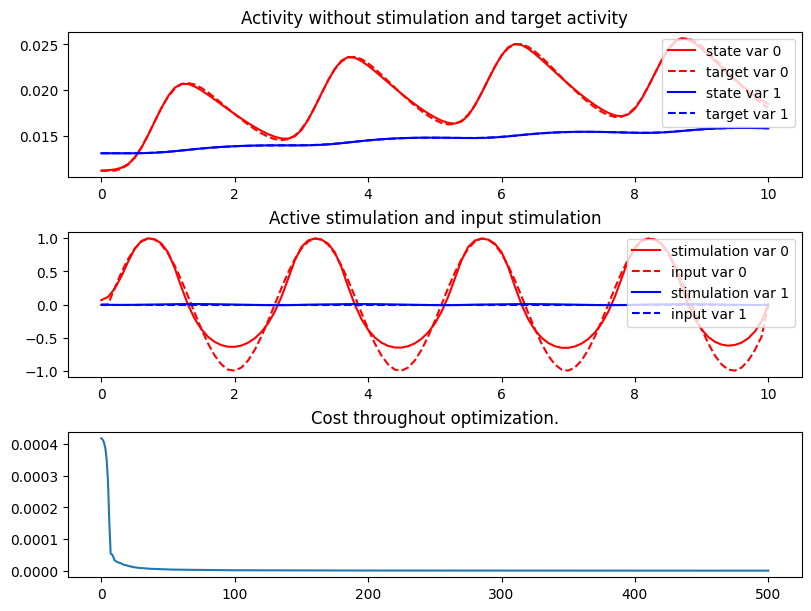

In [ ]:
# We set the external stimulation to zero. This is the "initial guess" for the OC algorithm
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25))
model_controlled.weights["w_p"] = 1. # default value 1
model_controlled.weights["w_2"] = 0. # default value 0

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control

plot_oc_singlenode(duration, dt, state, target, control, target_input, model_controlled.cost_history)

Compute control for a deterministic system
Cost in iteration 0: 1.4092613745894185e-07
Cost in iteration 25: 1.3051113114486598e-07
Cost in iteration 50: 1.2069164098268006e-07
Cost in iteration 75: 1.1215971283577444e-07
Cost in iteration 100: 1.04563274527841e-07
Final cost : 1.04563274527841e-07


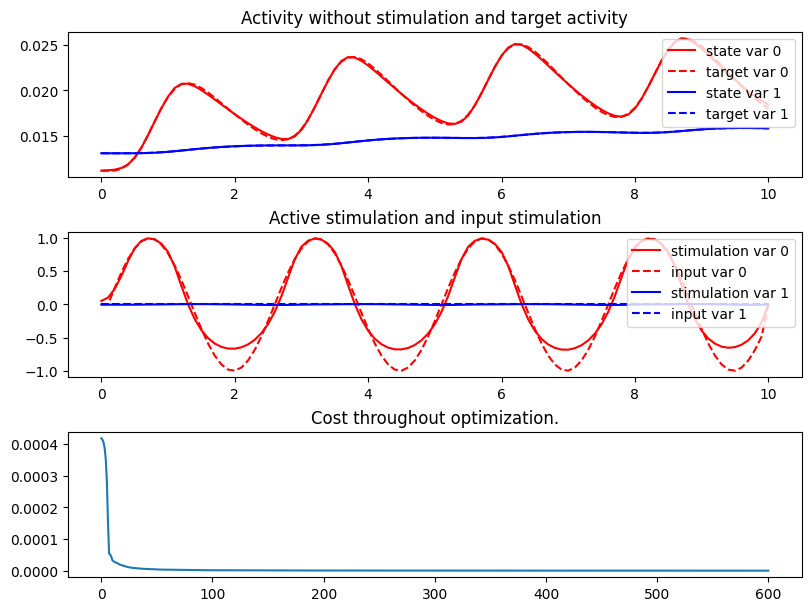

In [ ]:
# Do another 100 iterations if you want to.
# Repeated execution will continue with further 100 iterations.
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_singlenode(duration, dt, state, target, control, target_input, model_controlled.cost_history)

### Network case

Let us know study a simple 2-node network of model oscillators. We first define the coupling matrix and the distance matrix. We can then initialize the model.

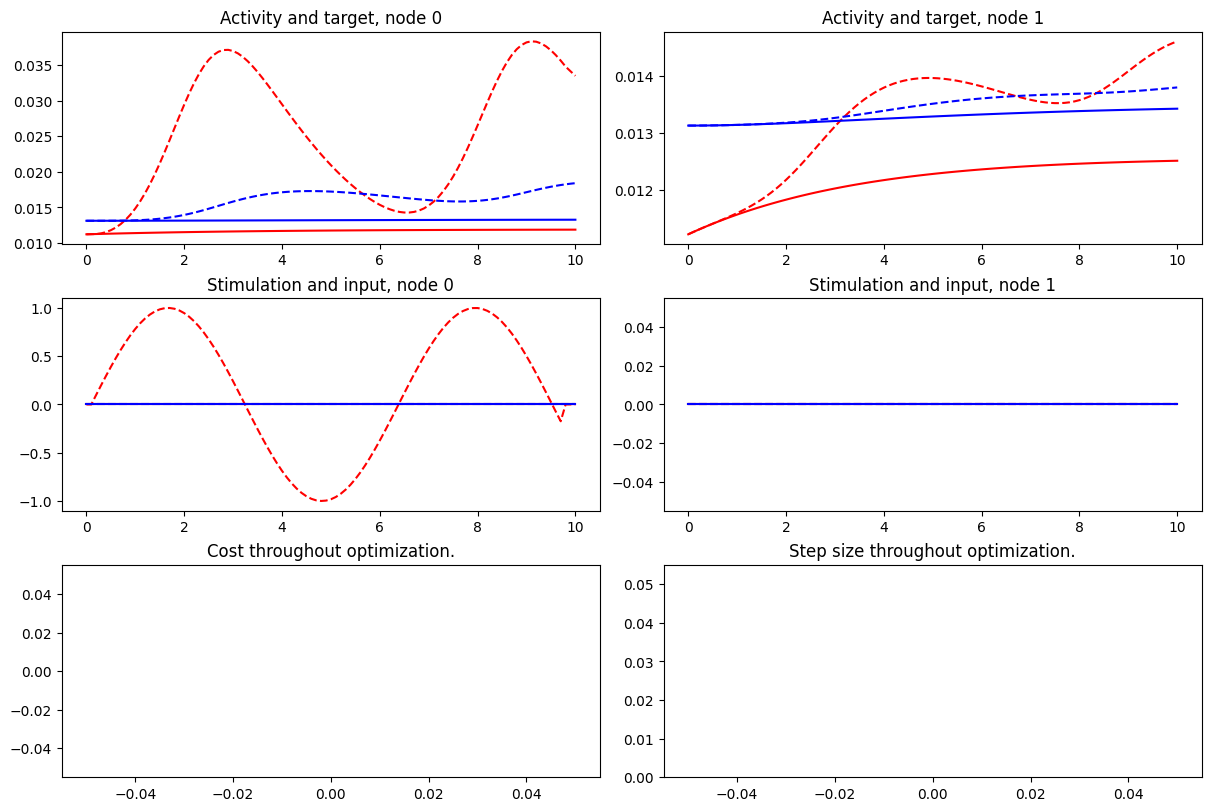

In [ ]:
cmat = np.array( [[0., 0.5], [1., 0.]] )  # diagonal elements are zero, connection strength is 1 (0.5) from node 0 to node 1 (from node 1 to node 0)
dmat = np.array( [[0., 0.], [0., 0.]] )  # no delay

model = WCModel(Cmat=cmat, Dmat=dmat)

# we define the control input matrix to enable or disable certain channels and nodes
control_mat = np.zeros( (model.params.N, len(model.state_vars)) )
control_mat[0,0] = 1. # only allow inputs in x-channel in node 0

model.params.K_gl = 5.

model.params["duration"] = duration
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-3] = np.sin(np.arange(0,duration-0.3, dt)) # other functions or random values can be used as well
model.params["exc_init"] = np.vstack( [x_init, x_init] )
model.params["inh_init"] = np.vstack( [y_init, y_init] )


# We set the stimulus in x and y variables, and run the simulation
input_nw = np.concatenate( (np.vstack( [control_mat[0,0] * input, control_mat[0,1] * input] )[np.newaxis,:,:],
                            np.vstack( [control_mat[1,0] * input, control_mat[1,1] * input] )[np.newaxis,:,:]), axis=0)
zero_input_nw = np.concatenate( (np.vstack( [zero_input, zero_input] )[np.newaxis,:,:],
                                 np.vstack( [zero_input, zero_input] )[np.newaxis,:,:]), axis=0)

model.params["exc_ext"] = input_nw[:,0,:]
model.params["inh_ext"] = input_nw[:,1,:]

model.run()

# Define the result of the stimulation as target
target = np.concatenate( (np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]
model.run()

# combine initial value and simulation result to one array
state =  np.concatenate( (np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

plot_oc_network(model.params.N, duration, dt, state, target, zero_input_nw, input_nw)

Compute control for a deterministic system
Cost in iteration 0: 8.117061134315108e-06
Cost in iteration 25: 3.991029159085846e-07
Cost in iteration 50: 2.0940293478671185e-07
Cost in iteration 75: 1.11776566406223e-07
Cost in iteration 100: 6.633087062703058e-08
Cost in iteration 125: 3.767129904338891e-08
Cost in iteration 150: 2.337898889177354e-08
Cost in iteration 175: 1.6124862923969687e-08
Cost in iteration 200: 1.1647682670737143e-08
Cost in iteration 225: 8.926692122664385e-09
Cost in iteration 250: 7.0546661142583194e-09
Cost in iteration 275: 5.8200152315059315e-09
Cost in iteration 300: 4.860088153479947e-09
Cost in iteration 325: 4.1868184248475905e-09
Cost in iteration 350: 3.671234703393019e-09
Cost in iteration 375: 3.2820026741717433e-09
Cost in iteration 400: 2.970711301045303e-09
Cost in iteration 425: 2.7216367205111153e-09
Cost in iteration 450: 2.5182704941078486e-09
Cost in iteration 475: 2.350788582742496e-09
Cost in iteration 500: 2.2010686605823463e-09
Final co

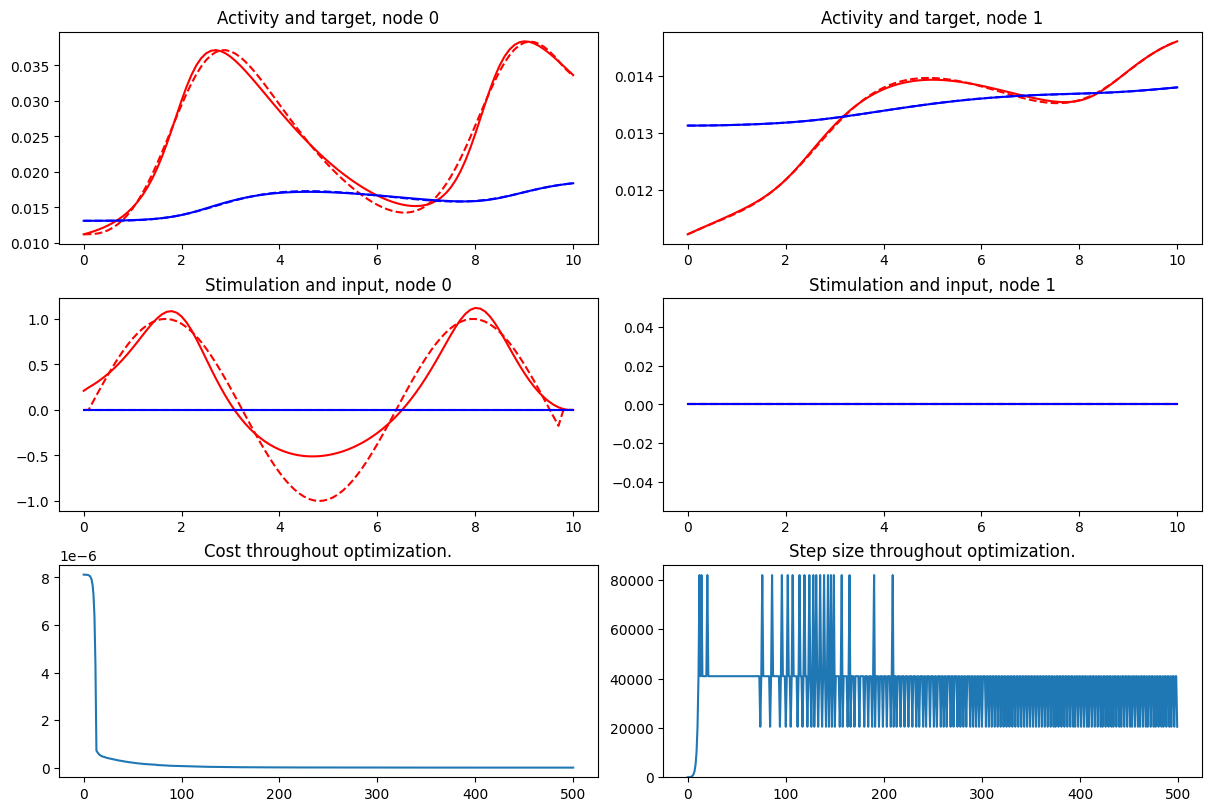

In [ ]:
# we define the precision matrix to specify, in which nodes and channels we measure deviations from the target
cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[1,0] = 1. # only measure in y-channel in node 1

# We set the external stimulation to zero. This is the "initial guess" for the OC algorithm
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25), control_matrix=control_mat, cost_matrix=cost_mat)

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control

plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

Compute control for a deterministic system
Cost in iteration 0: 2.2010686605823463e-09
Cost in iteration 25: 2.0784520596404367e-09
Cost in iteration 50: 1.966749124035962e-09
Cost in iteration 75: 1.870038718444721e-09
Cost in iteration 100: 1.7873019174123556e-09
Final cost : 1.7873019174123556e-09


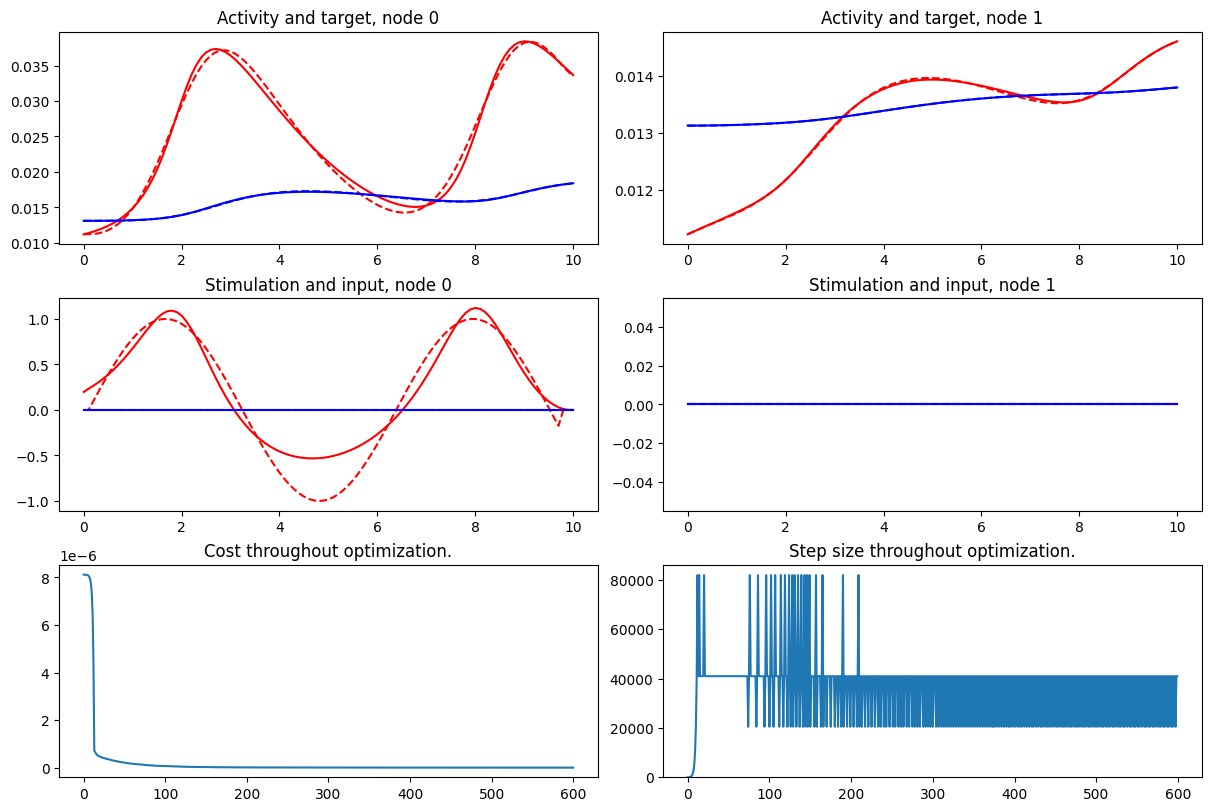

In [ ]:
# Do another 100 iterations if you want to.
# Repeated execution will continue with further 100 iterations.
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

### Delayed network of neural populations

We now consider a network topology with delayed signalling between the two nodes.

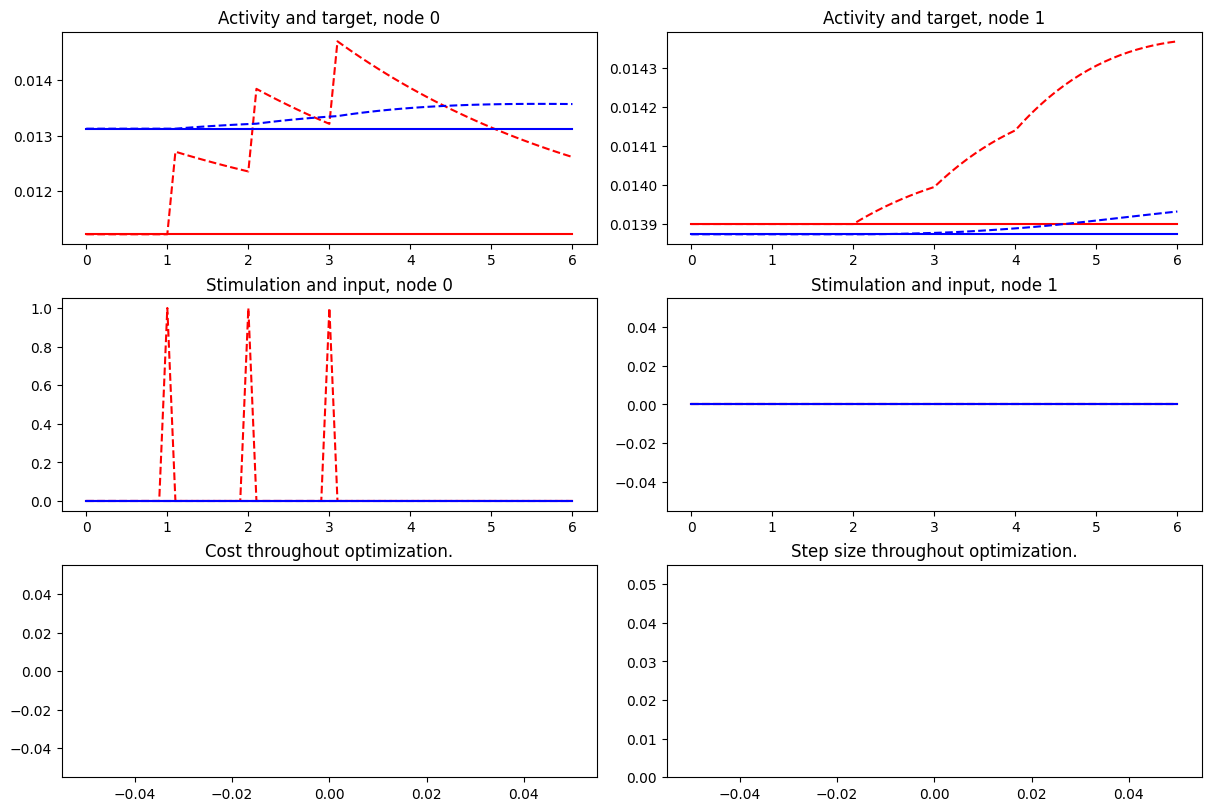

In [ ]:
cmat = np.array( [[0., 0.], [1., 0.]] ) # diagonal elements are zero, connection strength is 1 from node 0 to node 1
dmat = np.array( [[0., 0.], [18, 0.]] ) # distance from 0 to 1, delay is computed by dividing by the signal speed params.signalV

model = WCModel(Cmat=cmat, Dmat=dmat)

duration, dt = 2000., 0.1
model.params.duration = duration
model.params.dt = dt
model.params.K_gl = 10.

model.run()

e0 = model.exc[0,-1]
e1 = model.exc[1,-1]
i0 = model.inh[0,-1]
i1 = model.inh[1,-1]

maxdelay = model.getMaxDelay()

model.params["exc_init"] = np.array([[e0] * (maxdelay + 1), [e1] * (maxdelay + 1) ])
model.params["inh_init"] = np.array([[i0] * (maxdelay + 1), [i1] * (maxdelay + 1) ])

duration = 6.
model.params.duration = duration
model.run()

# we define the control input matrix to enable or disable certain channels and nodes
control_mat = np.zeros( (model.params.N, len(model.state_vars)) )
control_mat[0,0] = 1. # only allow inputs in E-channel in node 0

zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = zero_input.copy()
input[0,10] = 1. 
input[0,20] = 1.
input[0,30] = 1. # Three pulses as control input

input_nw = np.concatenate( (np.vstack( [control_mat[0,0] * input, control_mat[0,1] * input] )[np.newaxis,:,:],
                            np.vstack( [control_mat[1,0] * input, control_mat[1,1] * input] )[np.newaxis,:,:]), axis=0)
zero_input_nw = np.concatenate( (np.vstack( [zero_input, zero_input] )[np.newaxis,:,:],
                                 np.vstack( [zero_input, zero_input] )[np.newaxis,:,:]), axis=0)

model.params["exc_ext"] = input_nw[:,0,:]
model.params["inh_ext"] = input_nw[:,1,:]
model.run()

# Define the result of the stimulation as target
target = np.concatenate( (np.stack( (model.params["exc_init"][:,-1], model.params["inh_init"][:,-1]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]
model.run()

# combine initial value and simulation result to one array
state = np.concatenate( (np.stack( (model.params["exc_init"][:,-1], model.params["inh_init"][:,-1]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)
plot_oc_network(model.params.N, duration, dt, state, target, zero_input_nw, input_nw)

Compute control for a deterministic system
Cost in iteration 0: 1.7928350533912262e-07
Cost in iteration 25: 3.261640346841477e-10
Cost in iteration 50: 1.0779524630417724e-10
Cost in iteration 75: 8.574159593586424e-11
Cost in iteration 100: 7.606917593646062e-11
Cost in iteration 125: 7.030832625940234e-11
Cost in iteration 150: 6.604190402100834e-11
Cost in iteration 175: 6.251353168542466e-11
Cost in iteration 200: 5.957299348104675e-11
Cost in iteration 225: 5.679788234926844e-11
Cost in iteration 250: 5.436441341054896e-11
Cost in iteration 275: 5.220943426960374e-11
Cost in iteration 300: 5.028985793307416e-11
Cost in iteration 325: 4.857204489591882e-11
Cost in iteration 350: 4.708332788067809e-11
Cost in iteration 375: 4.566199765058689e-11
Cost in iteration 400: 4.438717405720476e-11
Cost in iteration 425: 4.323698275134953e-11
Cost in iteration 450: 4.2194754152020387e-11
Cost in iteration 475: 4.12460884276137e-11
Cost in iteration 500: 4.0379430193142616e-11
Final cost : 4

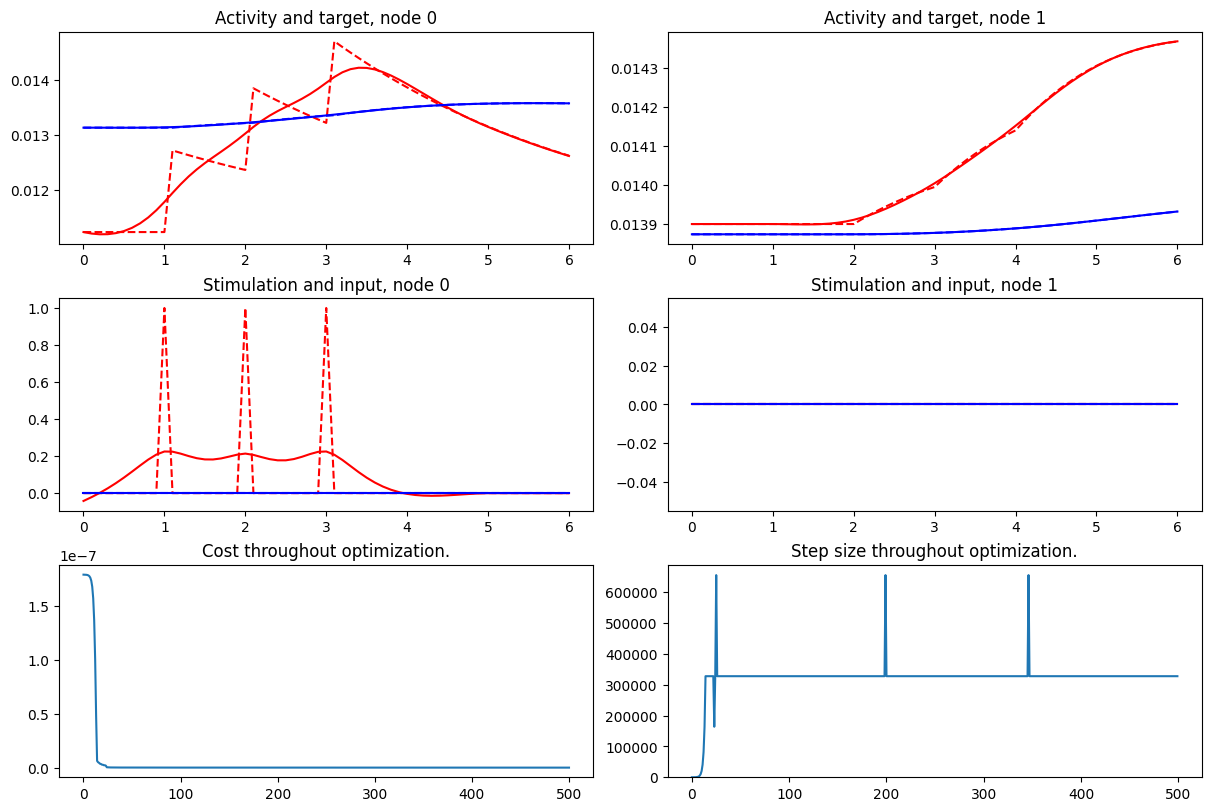

In [ ]:
# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25), control_matrix=control_mat, cost_matrix=cost_mat)

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

Compute control for a deterministic system
Cost in iteration 0: 4.0379430193142616e-11
Cost in iteration 25: 3.958449761829644e-11
Cost in iteration 50: 3.885283256315931e-11
Cost in iteration 75: 3.8176788194032465e-11
Cost in iteration 100: 3.755000697286012e-11
Final cost : 3.755000697286012e-11


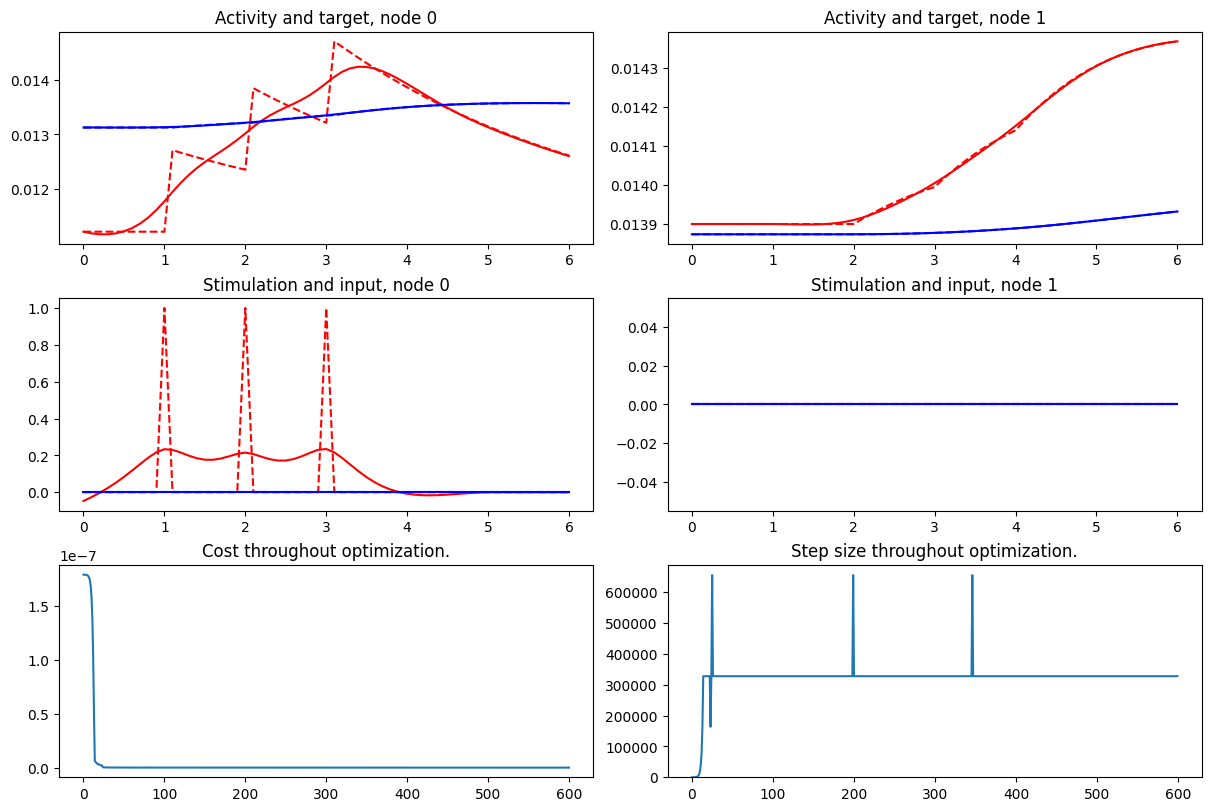

In [ ]:
# perofrm another 100 iterations to improve result
# repeat execution to add another 500 iterations
# converence to the input stimulus is relatively slow for the WC nodel
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

### Whole-brain network model: force oscillations

We construct a whole-brain network model and force it to oscillate, starting from a state of constant high or low activity.

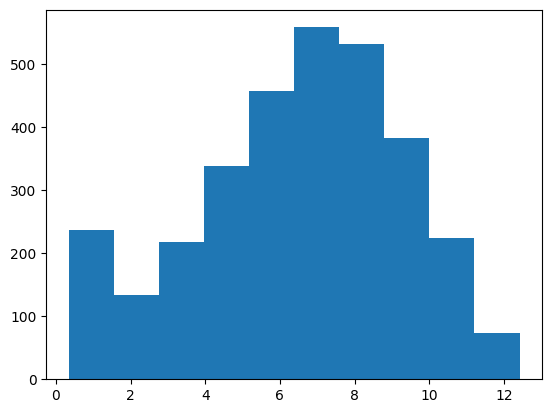

In [3]:
from neurolib.utils.loadData import Dataset
ds = Dataset("hcp")  #alternatively, you can use Dataset("gw")

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
duration = 60.
model.params['duration'] = duration
model.params['K_gl'] = 1.0

N = model.params.N
dt = model.params.dt

# set static external input to find a state of constant high activity
model.params['exc_ext_baseline'] = 0.
model.params['inh_ext_baseline'] = 1.

model.run()

dentries = []
for n in range(N):
    for k in range(n+1, N):
        dentries.append(model.params.lengthMat[n,k]/ model.params.signalV)

plt.hist(dentries)
plt.show()

# for up state, chose e_ext = 3, i_ext = 0
for n in range(N):
    model.params["exc_init"][n,-1] = model.exc[n, -1]
    model.params["inh_init"][n,-1] = model.inh[n, -1]

model.run()

In [4]:
# set target oscillation period; as the inter-areal delay is centered around 7, we chose this value as the target period, such that network effects can be leveraged by the optimal control
target_period = 7.

# set cost matrix and control matrix
cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[:,0] = 1. # only measure in exc channel in all nodes

control_mat = np.zeros( (model.params.N, len(model.input_vars)) )
control_mat[:,0] = 1. # only enable inputs to exc channel in all nodes

# set control interval to [10, 90]
control_interval = [50, 550]

control_init = np.zeros((N, 2, int(duration/model.params.dt)+1))
for n in range(N):
    control_init[n,0,control_interval[0]:control_interval[1]] = 0.5*(1. + np.sin(np.linspace(-0.5*np.pi, 7.5*np.pi, control_interval[1] - control_interval[0])))

We first compute the control using the enery cost. This will yield control signals that target all network nodes at low input strength.

In [ ]:
# initialize control signals
control_e, control_ds, control_ts = None, None, None

In [ ]:
# read control signals from file (optimization is time-consuming)
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'rb') as handle:
    [control_e, control_ds, control_ts] = pickle.load(handle)

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -1.3221896576980714
Cost in iteration 1: -1.7742096629285382
Final cost : -1.7742096629285382
Compute control for a deterministic system
Cost in iteration 0: 1.5079799707244466
Cost in iteration 1: -131568.58644330618
Final cost : -131568.58644330618
Compute control for a deterministic system
Cost in iteration 0: 55461.621259232445
Cost in iteration 1: 10573.899298236927
Cost in iteration 2: 3561.1265929892497
Cost in iteration 3: 295.63801453817723
Cost in iteration 4: 169.87610056510584
Cost in iteration 5: -58.46176303145694
Final cost : -58.46176303145694


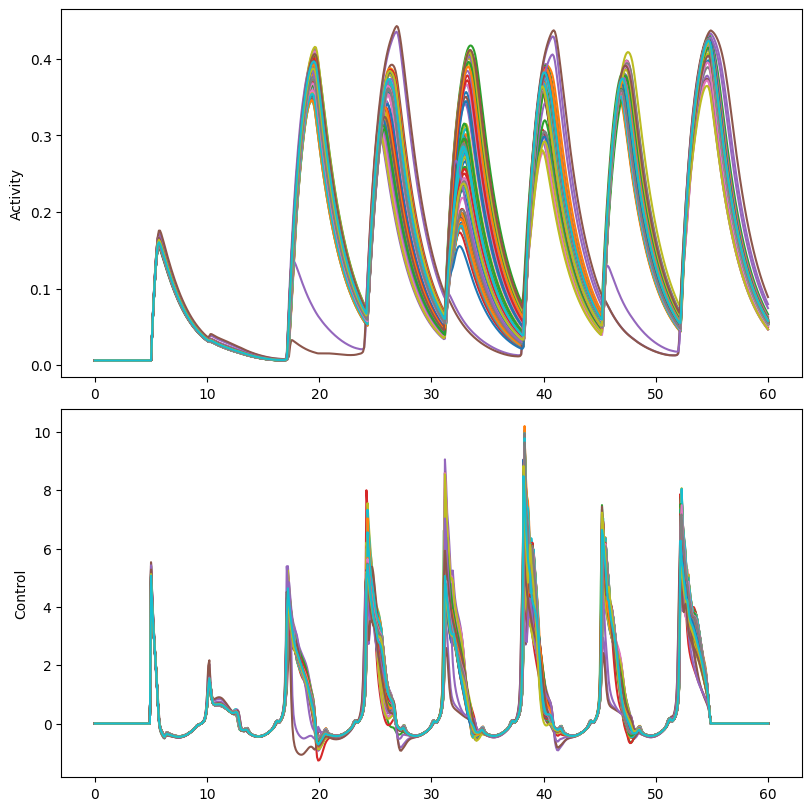

In [ ]:
model_controlled_e = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_e.weights["w_p"] = 0.
model_controlled_e.weights["w_2"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"

model_controlled_e.channelwise_optimization = False
model_controlled_e.step =  2*1e1
model_controlled_e.weights["w_f_osc"] = 1e8
model_controlled_e.optimize(1)

model_controlled_e.weights["w_f_osc"] = 0.
model_controlled_e.weights["w_f_sync"] = 3*1e7
model_controlled_e.step =  1e2
model_controlled_e.optimize(1)

model_controlled_e.weights["w_f_sync"] = 2*1e6
model_controlled_e.optimize(5)

In [46]:
limweight = 1.38 * 1e6

while model_controlled_e.weights["w_f_sync"] > limweight:
    total_cost = model_controlled_e.compute_total_cost()
    sp_cost = cost_functions.control_strength_cost(model_controlled_e.control, model_controlled_e.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_e.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_e.step =  1e1
    model_controlled_e.weights["w_f_sync"] = max(weight, limweight)
    model_controlled_e.optimize(2)

    control_e = model_controlled_e.control

In [65]:
# read from saved data, if results have been computed previously
if type(control_e) != type(None):
    model_controlled_e.control = control_e.copy()
    model_controlled_e.update_input()

# re-run this code to run another 100 iterations
model_controlled_e.channelwise_optimization = False
model_controlled_e.optimize(100)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_e.channelwise_optimization = True
model_controlled_e.optimize(100)

control_e = model_controlled_e.control

Compute control for a deterministic system
Cost in iteration 0: -11.356192305121112
Cost in iteration 1: -11.359300089377939
Cost in iteration 2: -11.361508411903742
Cost in iteration 3: -11.368936781577759
Cost in iteration 4: -11.372446954112092
Cost in iteration 5: -11.376484353634623
Cost in iteration 6: -11.380351336868443
Cost in iteration 7: -11.381986843320192
Cost in iteration 8: -11.38739504437308
Cost in iteration 9: -11.390208392658678
Cost in iteration 10: -11.393962155917507
Cost in iteration 11: -11.397281507366642
Cost in iteration 12: -11.39878046380727
Cost in iteration 13: -11.403594218722901
Cost in iteration 14: -11.406056334624736
Cost in iteration 15: -11.409457466337699
Cost in iteration 16: -11.41235698811488
Cost in iteration 17: -11.413637156575533
Cost in iteration 18: -11.41798704388475
Cost in iteration 19: -11.420185329022388
Cost in iteration 20: -11.423220355424746
Cost in iteration 21: -11.425831919532357
Cost in iteration 22: -11.426778881181235
Cost 

In [49]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

We then compute the control using the directional sparsity cost. This will yield control signals that target a subset of network nodes.

In [ ]:
model_controlled_ds = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval)#, cost_interval=control_interval)
model_controlled_ds.weights["w_p"] = 0.
model_controlled_ds.weights["w_1D"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"

model_controlled_ds.channelwise_optimization = True

# reduce weight iteratively for initialization
model_controlled_ds.step =  1e6
model_controlled_ds.weights["w_f_osc"] = 1e6
model_controlled_ds.optimize(1)

model_controlled_ds.weights["w_f_osc"] = 0.
model_controlled_ds.cost_interval = control_interval

model_controlled_ds.weights["w_f_sync"] = 3*1e7
model_controlled_ds.step =  1e2
model_controlled_ds.optimize(1)

control_ds = model_controlled_ds.control

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.04517089309171711
Cost in iteration 1: -6.791195699977962
Final cost : -6.791195699977962
Compute control for a deterministic system
Cost in iteration 0: 27.267627756545185
Cost in iteration 1: -10.057528651136437
Final cost : -10.057528651136437


In [37]:
limweight = 1.5 * 1e6

while model_controlled_ds.weights["w_f_sync"] > limweight:
    total_cost = model_controlled_ds.compute_total_cost()
    sp_cost = cost_functions.control_strength_cost(model_controlled_ds.control, model_controlled_ds.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_ds.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_ds.step =  1e1
    model_controlled_ds.weights["w_f_sync"] = max(weight, limweight)
    model_controlled_ds.optimize(3)

    control_ds = model_controlled_ds.control

weight =  1936775.247312592
Compute control for a deterministic system
Cost in iteration 0: -1.6837020666571334e-10
Cost in iteration 1: -0.4161975801333142
Cost in iteration 2: -4.794424163687665
Cost in iteration 3: -8.980181331712629
Final cost : -8.980181331712629
weight =  1883448.5644243425
Compute control for a deterministic system
Cost in iteration 0: -1.6842705008457415e-10
Cost in iteration 1: -0.06573382232426184
Cost in iteration 2: -4.313688763920993
Cost in iteration 3: -7.773617491210587
Final cost : -7.773617491210587
weight =  1838043.1161213708
Compute control for a deterministic system
Cost in iteration 0: -1.7121237760875374e-10
Cost in iteration 1: -0.0014309905118921051
Cost in iteration 2: -4.476900869891722
Cost in iteration 3: -7.413318397558783
Final cost : -7.413318397558783
weight =  1794300.6290567517
Compute control for a deterministic system
Cost in iteration 0: -1.694502316240687e-10
Cost in iteration 1: -0.07245454473559221
Cost in iteration 2: -6.13514

In [68]:
# read from saved data, if results have been computed previously
if type(control_ds) != type(None):
    model_controlled_ds.control = control_ds.copy()
    model_controlled_ds.update_input()

# re-run the optimization for another 100 iterations, repeat until convergence
model_controlled_ds.optimize(100)

control_ds = model_controlled_ds.control

Compute control for a deterministic system
Cost in iteration 0: -55.359431346479425
Cost in iteration 1: -55.35950183962734
Cost in iteration 2: -55.359504156985736
Cost in iteration 3: -57.96673458218444
Cost in iteration 4: -63.574672527188
Cost in iteration 5: -63.58944472382262
Cost in iteration 6: -63.60054992299837
Cost in iteration 7: -66.90419496175429
Cost in iteration 8: -66.90697879886494
Cost in iteration 9: -66.92664272204593
Cost in iteration 10: -66.92733460982055
Cost in iteration 11: -66.93482016769576
Cost in iteration 12: -66.93717163392665
Cost in iteration 13: -66.94318155026082
Cost in iteration 14: -66.9479069993568
Cost in iteration 15: -66.94830218645558
Cost in iteration 16: -66.95762599984658
Cost in iteration 17: -66.96175112389989
Cost in iteration 18: -66.96461904029167
Cost in iteration 19: -66.96751129841982
Cost in iteration 20: -66.96991591899592
Cost in iteration 21: -66.9705442953798
Cost in iteration 22: -66.97275079423929
Cost in iteration 23: -66.

In [69]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

We then compute the control using the temporal sparsity cost. This will yield control signals that are nonzero only during short time spans during the control time interval

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 337.09392040593974
Cost in iteration 1: -63906.82495723837
Final cost : -63906.82495723837
Compute control for a deterministic system
Cost in iteration 0: 1349.7777870076816
Cost in iteration 1: 654.940185092441
Cost in iteration 2: -738.6943710193145
Final cost : -738.6943710193145


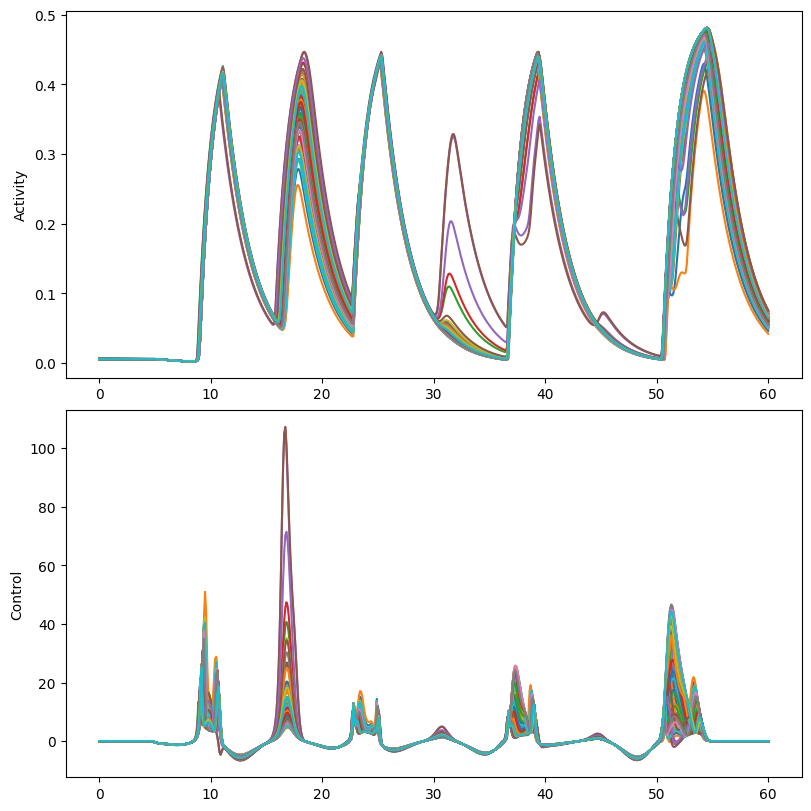

In [ ]:
model_controlled_ts = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_ts.weights["w_p"] = 0.
model_controlled_ts.weights["w_1T"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_ts.control = control_init.copy()
model_controlled_ts.update_input()

# we iteratively adjust the weight
model_controlled_ts.weights["w_f_osc"] = 1e8
model_controlled_ts.optimize(1)

model_controlled_ts.weights["w_f_osc"] = 0.
model_controlled_ts.weights["w_f_sync"] = 1e6
model_controlled_ts.optimize(2)

control_ts = model_controlled_ts.control

weight =  166410.66650485763
Compute control for a deterministic system
Cost in iteration 0: -22.809556631471423
Cost in iteration 1: -23.704757945756
Cost in iteration 2: -24.32400911820332
Final cost : -24.32400911820332


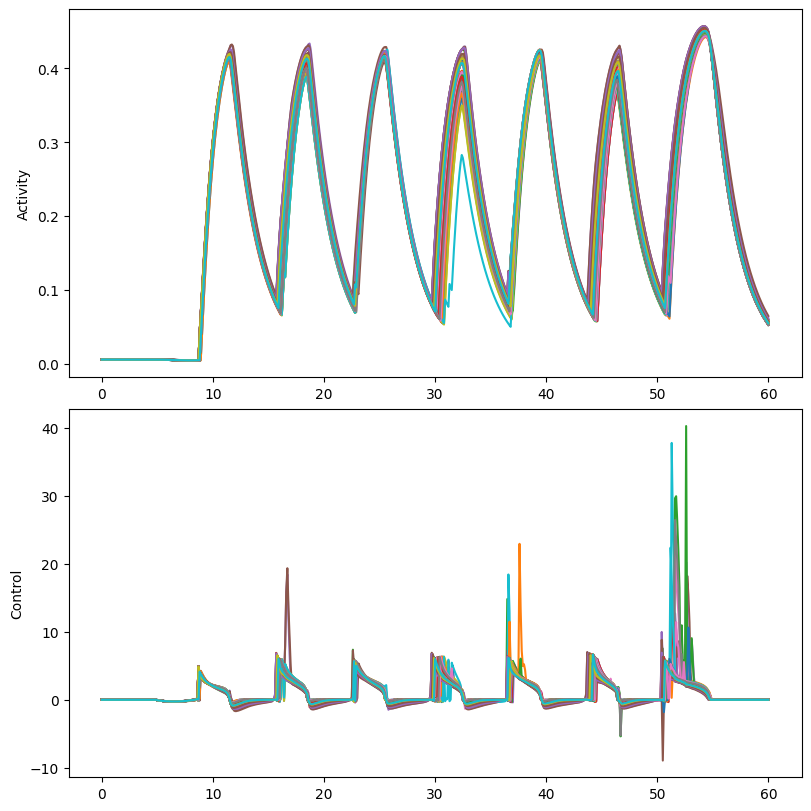

In [ ]:
limweight = 1.7 * 1e5

while model_controlled_ts.weights["w_f_sync"] > limweight:
    total_cost = model_controlled_ts.compute_total_cost()
    sp_cost = cost_functions.control_strength_cost(model_controlled_ts.control, model_controlled_ts.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_ts.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_ts.step =  1e1
    model_controlled_ts.weights["w_f_sync"] = max(weight, limweight)
    model_controlled_ts.optimize(2)

    control_ts = model_controlled_ts.control

In [71]:
# read from saved data, if results have been computed previously
if type(control_ts) != type(None):
    model_controlled_ts.control = control_ts.copy()
    model_controlled_ts.update_input()

# re-run this code to run another 20 iterations
model_controlled_ts.channelwise_optimization = False
model_controlled_ts.optimize(100)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_ts.channelwise_optimization = True
model_controlled_ts.optimize(100)

control_ts = model_controlled_ts.control

Compute control for a deterministic system
Cost in iteration 0: -45.83943184569512
Cost in iteration 1: -45.839432365317634
Cost in iteration 2: -45.839433269925166
Cost in iteration 3: -45.839434739579474
Cost in iteration 4: -45.83943671543648
Cost in iteration 5: -45.839437262298134
Cost in iteration 6: -45.839439944565584
Cost in iteration 7: -45.839441709592165
Cost in iteration 8: -45.83944273036491
Cost in iteration 9: -45.83944326423398
Cost in iteration 10: -45.839443280035994
Cost in iteration 11: -45.83944330490135
Cost in iteration 12: -45.83944331937391
Cost in iteration 13: -45.839443339216814
Cost in iteration 14: -45.83944335507181
Cost in iteration 15: -45.83944337335902
Cost in iteration 16: -45.83944338818196
Cost in iteration 17: -45.839443408744955
Cost in iteration 18: -45.839443421600436
Cost in iteration 19: -45.83944344415863
Cost in iteration 20: -45.839443455169885
Cost in iteration 21: -45.83944347649299
Cost in iteration 22: -45.83944349088074
Cost in itera

In [66]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

In [30]:
if type(control_e) != type(None):
    model_controlled_e.control = control_e.copy()
    model_controlled_e.update_input()

if type(control_ds) != type(None):
    model_controlled_ds.control = control_ds.copy()
    model_controlled_ds.update_input()

if type(control_ts) != type(None):
    model_controlled_ts.control = control_ts.copy()
    model_controlled_ts.update_input()

Plot all three cases for comparison

Compute control for a deterministic system
Cost in iteration 0: -11.551444214613184
Final cost : -11.551444214613184
Compute control for a deterministic system
Cost in iteration 0: -86.49511068425053
Final cost : -86.49511068425053
Compute control for a deterministic system
Cost in iteration 0: -45.839445028558885
Final cost : -45.839445028558885


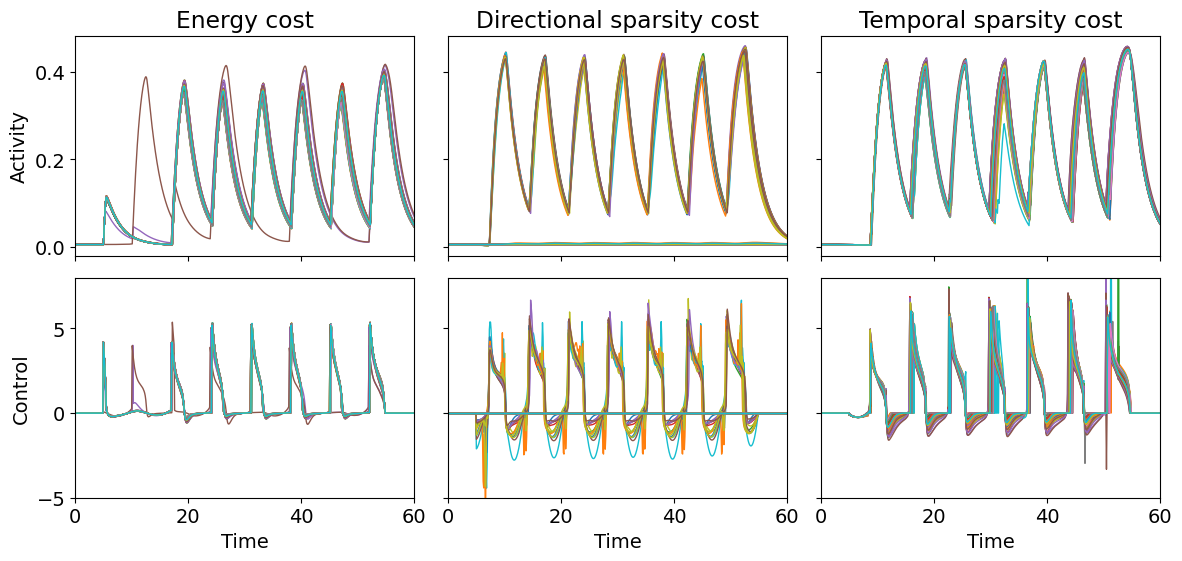

In [75]:
time = np.arange(0, duration+dt, dt)
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(2,3, figsize=(14,6), sharex=True, sharey="row")

model_controlled_e.optimize(0)
state = model_controlled_e.get_xs()
control_e = model_controlled_e.control

for n in range(N):
    ax[0,0].plot(time, state[n,0,:], linewidth=1)
    ax[1,0].plot(time, control_e[n,0,:], linewidth=1)

model_controlled_ds.optimize(0)
state = model_controlled_ds.get_xs()
control_ds = model_controlled_ds.control

for n in range(N):
    ax[0,1].plot(time, state[n,0,:], linewidth=1)
    ax[1,1].plot(time, control_ds[n,0,:], linewidth=1)

model_controlled_ts.optimize(0)
state = model_controlled_ts.get_xs()
control_ts = model_controlled_ts.control

for n in range(N):
    ax[0,2].plot(time, state[n,0,:], linewidth=1)
    ax[1,2].plot(time, control_ts[n,0,:], linewidth=1)

ax[0,0].set_xlim(0, duration)

ax[0,0].set_ylabel("Activity")
ax[1,0].set_ylabel("Control")

ax[1,0].set_ylim(-5, 8)

ax[1,0].set_xlabel("Time")
ax[1,1].set_xlabel("Time")
ax[1,2].set_xlabel("Time")

ax[0,0].set_title("Energy cost")
ax[0,1].set_title("Directional sparsity cost")
ax[0,2].set_title("Temporal sparsity cost")

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig("WB_osc.pdf")

plt.show()